# **Self RAG**

SELF-RAG는 언어 모델(LM)이 생성하는 텍스트의 정확도와 품질을 향상시키는 방법으로, 검색을 통해 관련 정보를 찾아내고, 모델이 자신의 출력 결과를 Reflection 할 수 있도록 합니다.

모델은 검색된 구절의 도움을 받아 텍스트를 생성한 후, reflection tokens을 생성하여 자신의 응답을 평가합니다. 이 토큰들은 모델에게 추가 정보가 필요한지, 아니면 응답이 완전하며 검색된 데이터에 의해 충분히 지원되는지를 알려줍니다.

Read the Paper : [Self RAG](https://arxiv.org/pdf/2310.11511)

## **Initial Setup**

In [1]:
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4 pandas==2.2.1

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.1
Uninstalling pandas-2.2.1:
  Successfully uninstalled pandas-2.2.1
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached pandas-2.2.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.1 which is incompatible.
transformers 4.50.0 requires tokenizers<0.22,>=0.21, but you have tokenizers 0.19.1 which is incompatible.


In [2]:
! pip install --q athina faiss-cpu langgraph pdfplumber

In [3]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ['ATHINA_API_KEY'] = userdata.get('ATHINA_API_KEY')

## **Indexing**

In [4]:
from langchain_community.document_loaders import PDFPlumberLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List, Annotated

import faiss
import numpy as np
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain.schema.document import Document
from langchain_community.vectorstores import FAISS

from langchain_core.output_parsers import StrOutputParser
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

from abc import ABC, abstractmethod
from operator import itemgetter
from langchain import hub

class RetrievalChain(ABC):
    def __init__(self):
        self.source_uri = None
        self.k = 10
        self.model_name = "gpt-4o-mini"

    @abstractmethod
    def load_documents(self, source_uris):
        """loader를 사용하여 문서를 로드합니다."""
        pass

    @abstractmethod
    def create_text_splitter(self):
        """text splitter를 생성합니다."""
        pass

    def split_documents(self, docs, text_splitter):
        """text splitter를 사용하여 문서를 분할합니다."""
        return text_splitter.split_documents(docs)

    def create_embedding(self):
        return OpenAIEmbeddings(model="text-embedding-3-small")

    def create_vectorstore(self, split_docs):
        embedding_model = self.create_embedding()

        # 문서에서 텍스트 추출 및 임베딩 생성
        texts = [doc.page_content for doc in split_docs]
        embeddings = embedding_model.embed_documents(texts)

        # numpy array로 명시적 변환
        embeddings_array = np.array(embeddings, dtype=np.float32)

        # FAISS 인덱스 초기화 (명확한 dimension 입력)
        dimension = embeddings_array.shape[1]
        index = faiss.IndexFlatL2(dimension)

        # index와 docstore_id 연결
        index_to_docstore_id = {i: str(i) for i in range(len(split_docs))}
        docstore = InMemoryDocstore({str(i): doc for i, doc in enumerate(split_docs)})

        # FAISS 벡터스토어 명시적으로 생성
        vectorstore = FAISS(
            embedding_function=embedding_model,
            index=index,
            docstore=docstore,
            index_to_docstore_id=index_to_docstore_id
        )

        # 문서 임베딩 명시적 추가
        vectorstore.add_embeddings(
            text_embeddings=list(zip(texts, embeddings))
        )

        return vectorstore

    def create_retriever(self, vectorstore):
        # retriever 생성
        dense_retriever = vectorstore.as_retriever(
            search_type="similarity", search_kwargs={"k": self.k}
        )
        return dense_retriever

    def create_model(self):
        return ChatOpenAI(model_name=self.model_name, temperature=0)

    def create_prompt(self):
        return hub.pull("teddynote/rag-prompt")

    @staticmethod
    def format_docs(docs):
        return "\n".join(docs)

    def create_chain(self):
        docs = self.load_documents(self.source_uri)
        text_splitter = self.create_text_splitter()
        split_docs = self.split_documents(docs, text_splitter)
        self.vectorstore = self.create_vectorstore(split_docs)
        self.retriever = self.create_retriever(self.vectorstore)
        model = self.create_model()
        prompt = self.create_prompt()
        self.chain = (
            {"question": itemgetter("question"), "context": itemgetter("context")}
            | prompt
            | model
            | StrOutputParser()
        )
        return self
def format_docs(docs):
    return "\n".join(
        [
            f"<document><content>{doc.page_content}</content><source>{doc.metadata['source']}</source><page>{int(doc.metadata['page'])+1}</page></document>"
            for doc in docs
        ]
    )


def format_searched_docs(docs):
    return "\n".join(
        [
            f"<document><content>{doc['content']}</content><source>{doc['url']}</source></document>"
            for doc in docs
        ]
    )


def format_task(tasks):
    # 결과를 저장할 빈 리스트 생성
    task_time_pairs = []

    # 리스트를 순회하면서 각 항목을 처리
    for item in tasks:
        # 콜론(:) 기준으로 문자열을 분리
        task, time_str = item.rsplit(":", 1)
        # '시간' 문자열을 제거하고 정수로 변환
        time = int(time_str.replace("시간", "").strip())
        # 할 일과 시간을 튜플로 만들어 리스트에 추가
        task_time_pairs.append((task, time))

    # 결과 출력
    return task_time_pairs

class PDFRetrievalChain(RetrievalChain):
    def __init__(
        self,
        source_uri: Annotated[str, "Source URI"],
        model_name="gpt-4o-mini",
        k: int = 6,
    ):
        self.source_uri = source_uri
        self.k = k
        self.model_name = model_name

    def load_documents(self, source_uris: List[str]):
        docs = []
        for source_uri in source_uris:
            loader = PDFPlumberLoader(source_uri)
            docs.extend(loader.load())

        return docs

    def format_docs(self, docs):
        return format_docs(docs)

    def create_text_splitter(self):
        return RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)

    def create_vectorstore(self, split_docs):
        embedding_model = self.create_embedding()
        embeddings = embedding_model.embed_documents([doc.page_content for doc in split_docs])

        # 여기서 추가적으로 디버깅 출력
        print("Embeddings type:", type(embeddings))
        print("Number of embeddings generated:", len(embeddings))
        print("Embedding dimension of the first document:", len(embeddings[0]))

        # 만약 embeddings가 numpy가 아니라면 변환
        embeddings_array = np.array(embeddings, dtype=np.float32)
        print("Shape of embeddings array:", embeddings_array.shape)

        return FAISS.from_embeddings(
            text_embeddings=list(zip([doc.page_content for doc in split_docs], embeddings)),
            embedding=embedding_model
        )

In [5]:
# load embedding model
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings()

In [6]:
# # load data
# from langchain.document_loaders import CSVLoader
# loader = CSVLoader("./context.csv")
# documents = loader.load()

In [7]:
# # split documents
# from langchain.text_splitter import RecursiveCharacterTextSplitter
# text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)
# documents = text_splitter.split_documents(documents)

In [8]:
# # create vectorstore
# from langchain.vectorstores import FAISS
# vectorstore = FAISS.from_documents(documents, embeddings)

In [9]:
# PDF 문서를 로드
pdf = PDFRetrievalChain(["대한민국 2050탄소중립 전략(LEDS 보고서).pdf"]).create_chain()

# retriever 와 chain을 생성
pdf_retriever = pdf.retriever
documents = pdf.chain

Embeddings type: <class 'list'>
Number of embeddings generated: 287
Embedding dimension of the first document: 1536
Shape of embeddings array: (287, 1536)


/usr/local/lib/python3.11/dist-packages/langsmith/client.py:277: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


## **Retriever**

In [10]:
# # create retriever
# retriever = vectorstore.as_retriever()

## **Document Grader**

In [11]:
# create grader for doc retriever
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_openai import ChatOpenAI

# define a data class
class GradeDocuments(BaseModel):
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with function call
llm = ChatOpenAI(temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt for the grader
system = """You are a grader assessing relevance of a retrieved document to a user question. \n
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)
/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1569: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  

In [12]:
# testing grader
question = "대한민국 정부는 탄소중립을 위해 국민 정책 참여 확대를 어떻게 의사결정 하는지 알아?"
docs = pdf_retriever.invoke(question)

print(retrieval_grader.invoke({"question": question, "document": docs}))

binary_score='yes'


## **RAG Chain**

In [13]:
# create document chain
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import ChatPromptTemplate

template = """"
You are a helpful assistant that answers questions based on the following context
Context: {context}
Question: {question}
Answer:

"""

prompt = ChatPromptTemplate.from_template(template)
llm = ChatOpenAI(temperature=0)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


rag_chain = prompt | llm | StrOutputParser()

In [14]:
# response
generation = rag_chain.invoke({"context": docs, "question": question})
generation

'대한민국 정부는 탄소중립을 위해 국민 정책 참여를 확대하기 위해 다양한 방법을 활용하고 있습니다. 예를 들어, LEDS(국가적 장기적 기후전략) 수립 과정에서는 보고서 수립 단계부터 민간 전문가 포럼을 운영하고, 민간 포럼의 논의 결과와 국민의 의견을 수렴하여 정부안을 수립하였습니다. 또한, 국민이 정책에 참여할 수 있는 기회와 정보를 제공하고, 국민들에게 정당한 의사결정권을 부여하여 정책 수립의 주체로서 활발한 참여를 유도하고 있습니다. 또한, 특정 계층에 집중되어 온 청소년, 노년층 등의 참여 기회를 확대하여 모든 국민이 정책에 참여할 수 있는 환경을 조성하고 있습니다.'

## **Hallucination Grader**

In [15]:
# create grader for hallucination
# define a data class
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# prompt for the grader
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1569: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1582: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo-0125 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


GradeHallucinations(binary_score='yes')

## **Answer Grader**
The answer grader evaluates whether an answer effectively addresses the given question.

In [16]:
# create grader for answer
# define a data class
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# prompt for the grader
system = """You are a grader assessing whether an answer addresses / resolves a question \n
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1569: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1582: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo-0125 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


GradeAnswer(binary_score='yes')

## **Create Graph**

### **Define Graph State**

In [17]:
# define a data class for state
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[str]

In [ ]:
# from langchain.schema import Document

# 문서 검색 : 질문을 기반으로 문서 검색
def retrieve(state):
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = pdf_retriever.invoke(question)
    return {"documents": documents, "question": question}

# 생성자 : 필터링 된 문서를 기반으로 RAG 방식으로 응답 생성
def generate(state):
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

# 평가 : 문서의 관련성을 평가하여 관련문서만 필터링
def grade_documents(state):
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}

# 조건부 재생성 : 관련 문서가 없으면 재생성 결정 (생성된 응답이 충분히 뒷받침되지 않는 경우 다시 생성하도록 하는 루프를 구성)
def decide_to_generate(state):

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION---"
        )
        return "no_relevant_documents"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

# 재평가 : hallucination_grader와 answer_grader를 통해 생성된 응답이 문서와 질문에 잘 맞는지 평가
def grade_generation_v_documents_and_question(state):

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

### **Build Graph**

In [19]:
# Build graph
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "no_relevant_documents": END,
    },
)

workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
    },
)

# Compile
app = workflow.compile()

In [20]:
# Final generation example 1 (relevant documents)
from pprint import pprint

inputs = {"question": "대한민국 정부는 탄소중립을 위해 국민 정책 참여 확대를 어떻게 의사결정 하는지 알아?"}
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    pprint("\n---\n")

if "generation" in value:
    pprint(value["generation"])
else:
    pprint("No relevant documents found or no generation produced.")

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
"Node 'generate':"
'\n---\n'
('대한민국 정부는 탄소중립을 위해 국민의 정책 참여를 확대하기 위해 다양한 방법을 활용하고 있습니다. 예를 들어, LEDS(국가 온실가스 '
 '감축 전략 및 시나리오)의 경우, 보고서 수립 단계부터 민간 전문가 포럼을 운영하고 민간 포럼의 논의 결과와 국민의 의견을 수렴하여 '
 '정부안을 수립하였습니다. 또한, 국민이 정책에 참여하는 기회와 정보를 제공하고, 국민에게 정당한 의사결정권을 부여하며, 특정 계층에 '
 '집중되어 온 청소년, 노년층 등의 참여 기회를 확대하는 것도 중요하다고 합니다. 이러한 방식을 통해 국민의 다양한 의견을 수렴하고 '
 '공정하고 합리적인 정책 결정을 이끌어내고 있습니다.')


In [21]:
# example 2 (no relevant documents)
from pprint import pprint

inputs = {"question": "AGENT 메모리의 종류가 어떻게 다른지 설명해주세요"}

for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    pprint("\n---\n")

if "generation" in value:
    pprint(value["generation"])
else:
    pprint("No relevant documents found or no generation produced.")

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION---
"Node 'grade_documents':"
'\n---\n'
'No relevant documents found or no generation produced.'


## **Preparing Data for Evaluation**

In [22]:
# Create a dataframe to store the question, context, and response
inputs = {"question": "대한민국 정부는 탄소중립을 위해 국민 정책 참여 확대를 어떻게 의사결정 하는지 알아?"}
outputs = []


for output in app.stream(inputs):
    for key, value in output.items():
        if key == "generate":  # Assuming 'generate' node produces the final output
            question = value["question"]
            documents = value["documents"]
            generation = value["generation"]

            # Combine document contents into a single string
            context = "\n".join(doc.page_content for doc in documents)

            # Append the result
            outputs.append({
                "query": question,
                "context": context,
                "response": generation,
            })

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


In [23]:
# Convert to DataFrame
import pandas as pd
df = pd.DataFrame(outputs)

In [24]:
df

,query,context,response
0,대한민국 정부는 탄소중립을 위해 국민 정책 참여 확대를 어떻게 의사결정 하는지 알아?,2.2 의사결정 거버넌스\n▍국민 정책 참여 확대\n과거에는 주로 정부가 정책을 수...,대한민국 정부는 탄소중립을 위해 국민의 정책 참여를 확대하기 위해 다양한 방법을 활...


In [25]:
# Convert to dictionary
df_dict = df.to_dict(orient='records')

# Convert context to list
for record in df_dict:
    if not isinstance(record.get('context'), list):
        if record.get('context') is None:
            record['context'] = []
        else:
            record['context'] = [record['context']]

## **Evaluation in Athina AI**

In [26]:
# set api keys for Athina evals
from athina.keys import AthinaApiKey, OpenAiApiKey
OpenAiApiKey.set_key(os.getenv('OPENAI_API_KEY'))
AthinaApiKey.set_key(os.getenv('ATHINA_API_KEY'))

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:502: UserWarning: <built-in function any> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(


In [27]:
# load dataset
from athina.loaders import Loader
dataset = Loader().load_dict(df_dict)

In [28]:
# evaluate
from athina.evals import DoesResponseAnswerQuery
DoesResponseAnswerQuery(model="gpt-4o").run_batch(data=dataset).to_df()

You can view your dataset at: https://app.athina.ai/develop/adf24214-4ac8-49fd-80a6-56ca3ecca5d9


,query,context,response,expected_response,display_name,failed,grade_reason,runtime,model,passed
0,대한민국 정부는 탄소중립을 위해 국민 정책 참여 확대를 어떻게 의사결정 하는지 알아?,"[2.2 의사결정 거버넌스\n▍국민 정책 참여 확대\n과거에는 주로 정부가 정책을 수립하고 사후에 국민들의 의견을 묻곤 했으나, 점점 정보 공유의 중요성이\n강조되고 인터넷 등 다양한 소통채널이 발달하면서 정책 수립단계에서부터 국민의 정책 참여 요구가\n증가하고 있다.\n특히 우리나라의 LEDS는 이러한 국민의 참여를 극대화하여 수립한 정책이다.\n보고서 수립 단계부터 민간 전문가 포럼을 9개월 동안 운영하였으며, 정부는 민간 포럼의 논의 결과와\n폭넓은 국민 의견수렴을 거쳐 정부안을 수립하였다.\n기후변화 정책은 국민이 가장 큰 이해당사자이다.\n지금보다 국민이 정책에 참여하는 기회와 정보가 폭넓게 제공되어야 하며, 국민은 정책 수립의 주체로서\n정당한 의사결정권을 부여받아야 한다.\n또한, 전문가, 산업계, 시민사회 등 특정 계층에 집중되어 그동안 정책 수립과정에서 소외됐던 청소년,\n노년층 등의 참여 기회를 확대하는 것도 중요하다.\n정책적 측면에서 유상할당 비율과 벤치...","대한민국 정부는 탄소중립을 위해 국민의 정책 참여를 확대하기 위해 다양한 방법을 활용하고 있습니다. 예를 들어, LEDS(국가적 장기적 기후전략) 수립 과정에서는 보고서 수립 단계부터 민간 전문가 포럼을 운영하고, 민간 포럼의 논의 결과와 국민의 의견을 수렴하여 정부안을 수립하였습니다. 또한, 국민이 정책에 참여하는 기회와 정보를 제공하고, 국민이 정책 수립의 주체로서 의사결정권을 부여하는 것이 중요하다고 인식하고 있습니다. 또한, 특정 계층에 집중되어 온 정책 수립과정에서 소외되었던 청소년, 노년층 등의 참여 기회를 확대하는 것도 고려하고 있습니다. 이러한 방식을 통해 국민의 다양한 의견을 수렴하고, 공정하고 합리적인 정책을 수립하고자 노력하고 있습니다.",None,Does Response Answer Query,False,"The response provides a detailed explanation of how the South Korean government is expanding public participation in policy-making for carbon neutrality. It mentions specific strategies such as the use of private expert forums, gathering public opinions, and ensuring diverse demographic participation, which directly addresses the user's query about decision-making processes for expanding public policy participation.",1477,gpt-4o,1.0


![스크린샷 2025-03-30 오전 10.10.59.png](<attachment:스크린샷 2025-03-30 오전 10.10.59.png>)
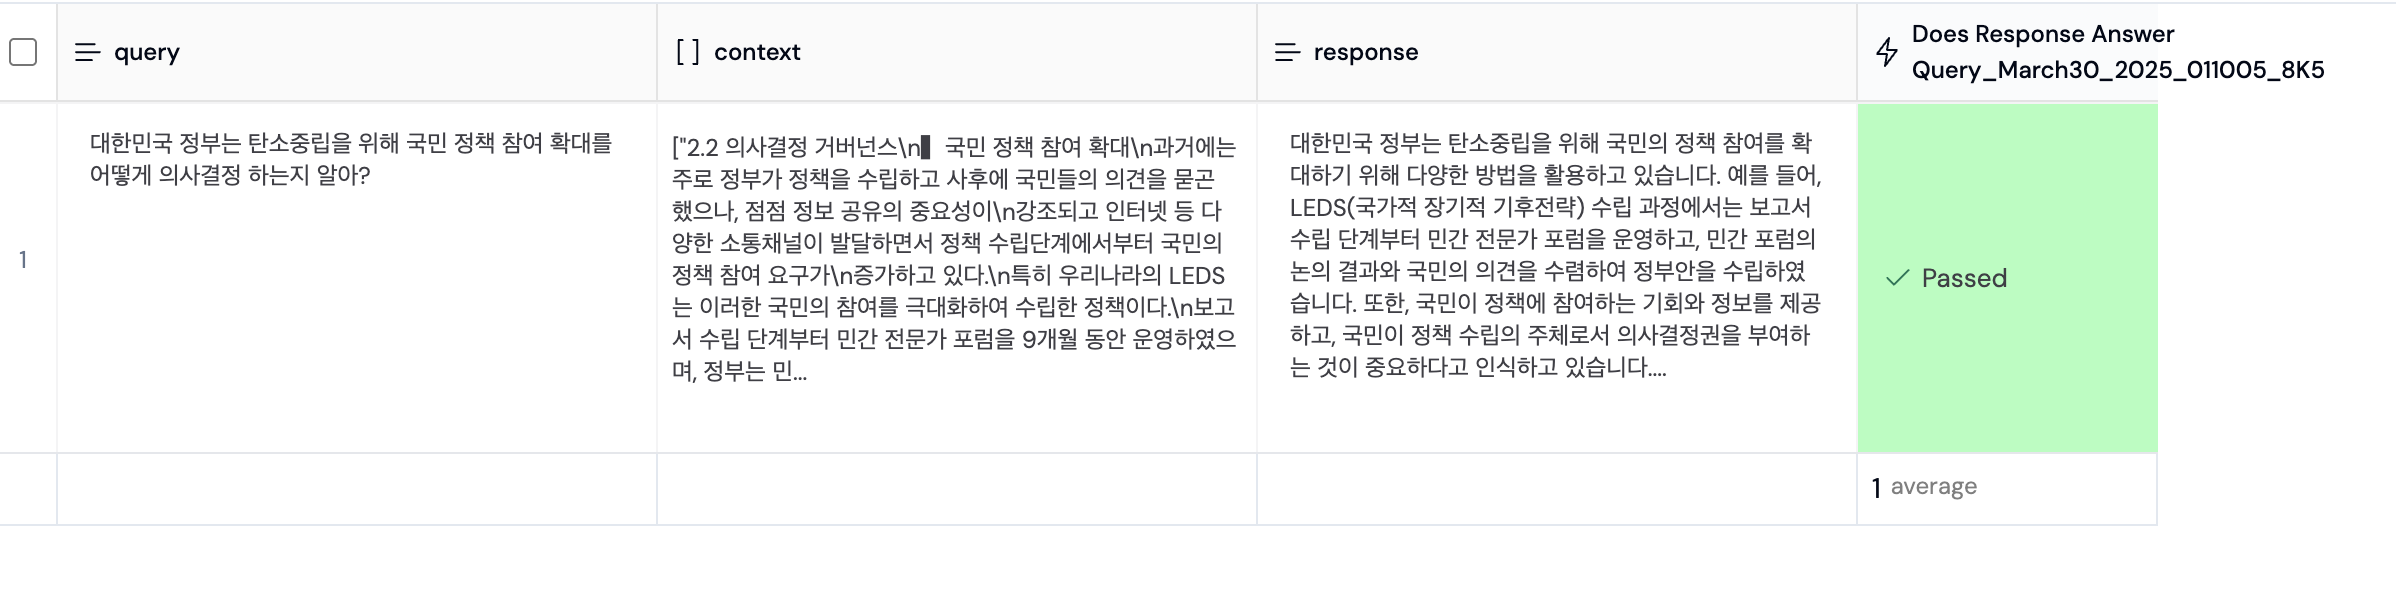